## 1. Config

In [12]:
# Check if any packages are missing or installed
import importlib, sys

pkgs = ["s3fs","zarr","xarray","torch","torchvision","numpy","matplotlib", "mlflow", "pandas"]
for p in pkgs:
    try:
        importlib.import_module(p)
        print(f"✅ {p:10} installed")
    except Exception as e:
        print(f"❌ {p:10} missing/broken -> {e.__class__.__name__}: {e}")

import numpy as np, torch
print("numpy:", np.__version__)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())


✅ s3fs       installed
✅ zarr       installed
✅ xarray     installed
✅ torch      installed
✅ torchvision installed
✅ numpy      installed
✅ matplotlib installed
✅ mlflow     installed
✅ pandas     installed
numpy: 1.26.4
torch: 2.6.0
cuda available: True


In [13]:
# Install missing packages
#%pip install -q zarr xarray

## 2. Imports

In [14]:
import s3fs
import xarray as xr
import re
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from tqdm import tqdm
import glob
import matplotlib.pyplot as plt
import os
from pathlib import Path
import mlflow
import pandas as pd

## 3. Data

In [2]:
# HUC_MARITIME = [17020009, 17020011, 17110005, 17110006, 17110009]
# HUC_08_list = HUC_MARITIME
# HUC8_SET = {str(h) for h in HUC_08_list}

# zarr_dirs_all = glob.glob("data/*.zarr")

# def huc10_from_name(p: str) -> str:
#     # expects: huc10_<HUC10ID>_24x24.zarr
#     name = Path(p).name
#     return name.split("_")[1]  # '1701030201'

# zarr_dirs = [p for p in zarr_dirs_all if huc10_from_name(p)[:8] in HUC8_SET]
# print(f"Found {len(zarr_dirs)} / {len(zarr_dirs_all)} zarrs for HUC8s: {sorted(HUC8_SET)}")

zarr_dirs =  glob.glob("data/*.zarr")

datasets = []
watershed_ids = []

for path in zarr_dirs:
    ds_single = xr.open_zarr(path, consolidated=True)

    # Extract huc10_id from attributes
    huc_id = ds_single.attrs["huc10_id"]

    datasets.append(ds_single)
    watershed_ids.append(huc_id)

# Concatenate
ds = xr.concat(datasets, dim="watershed")

# Assign watershed coordinate labels
ds = ds.assign_coords(watershed=("watershed", watershed_ids))

In [3]:
ds 

<xarray.Dataset> Size: 15GB
Dimensions:     (watershed: 91, y: 24, x: 24, day: 14487)
Coordinates:
  * watershed   (watershed) <U10 4kB '1701030201' '1701030202' ... '1711000907'
  * y           (y) int32 96B 0 1 2 3 4 5 6 7 8 9 ... 15 16 17 18 19 20 21 22 23
  * x           (x) int32 96B 0 1 2 3 4 5 6 7 8 9 ... 15 16 17 18 19 20 21 22 23
  * day         (day) datetime64[ns] 116kB 1983-01-31 1983-02-01 ... 2022-09-29
Data variables: (12/14)
    elev        (watershed, y, x) float32 210kB dask.array<chunksize=(1, 24, 24), meta=np.ndarray>
    huc12_id    (watershed, y, x) int64 419kB dask.array<chunksize=(1, 24, 24), meta=np.ndarray>
    lat         (watershed, y, x) float32 210kB dask.array<chunksize=(1, 24, 24), meta=np.ndarray>
    lon         (watershed, y, x) float32 210kB dask.array<chunksize=(1, 24, 24), meta=np.ndarray>
    mask        (watershed, y, x) uint8 52kB dask.array<chunksize=(1, 24, 24), meta=np.ndarray>
    pr          (watershed, day, y, x) float32 3GB dask.array<chunksize=(1, 3622, 6, 12), meta=np.ndarray>
    ...          ...
    swe_target  (watershed, day, y, x) float32 3GB dask.array<chunksize=(1, 3622, 6, 12), meta=np.ndarray>
    swe_today   (watershed, day, y, x) float32 3GB dask.array<chunksize=(1, 3622, 6, 12), meta=np.ndarray>
    tavg        (watershed, day, y, x) float32 3GB dask.array<chunksize=(1, 3622, 6, 12), meta=np.ndarray>
    valid_swe   (watershed, y, x) uint8 52kB dask.array<chunksize=(1, 24, 24), meta=np.ndarray>
    x5070       (watershed, y, x) float32 210kB dask.array<chunksize=(1, 24, 24), meta=np.ndarray>
    y5070       (watershed, y, x) float32 210kB dask.array<chunksize=(1, 24, 24), meta=np.ndarray>
Attributes: (12/14)
    huc10_id:                  1701030201
    huc10_height:              5
    huc10_width:               8
    final_size_height:         24
    final_size_width:          24
    placement_top:             9
    ...                        ...
    crs:                       EPSG:5070
    snow_class_flag_values:    [1, 2, 3, 4, 5, 6, 7, 8]
    snow_class_flag_meanings:  tundra boreal_forest maritime ephemeral prairi...
    huc12_id_note:             int64 HUC12 code per pixel; 0 = outside HUC10 ...
    valid_swe_note:            1 = inside HUC10 and no day is NaN at this pix...
    note:                      Values sampled by bilinear interpolation at 4k...

### 3.1 Dataset

In [4]:
class SWESeqDataset(Dataset):
    def __init__(self, ds, seq_len=90, day_mask=None):
        self.seq_len = seq_len

        # Optional: subset days first (train/val split)
        if day_mask is not None:
            ds = ds.sel(day=ds.day[day_mask])

        # ---- Load arrays into RAM once (fast __getitem__) ----
        # Static
        self.elev = torch.tensor(ds["elev"].values, dtype=torch.float32)
        self.valid_mask = torch.tensor(ds["valid_swe"].values, dtype=torch.float32)

        # Dynamic
        self.pr = torch.tensor(ds["pr"].values, dtype=torch.float32)
        self.tavg = torch.tensor(ds["tavg"].values, dtype=torch.float32)
        self.swe_lag30 = torch.tensor(ds["swe_lag30"].values, dtype=torch.float32)
        self.swe_target = torch.tensor(ds["swe_target"].values, dtype=torch.float32)

        # ---- Clean NaNs ONCE ----
        self.pr = torch.nan_to_num(self.pr, nan=0.0)
        self.tavg = torch.nan_to_num(self.tavg, nan=0.0)
        self.swe_lag30 = torch.nan_to_num(self.swe_lag30, nan=0.0)
        self.swe_target = torch.nan_to_num(self.swe_target, nan=0.0)
        self.elev = torch.nan_to_num(self.elev, nan=0.0)

        # ---- Dimensions ----
        self.n_watersheds = self.pr.shape[0]
        self.n_days = self.pr.shape[1]

        # Because target uses (day_idx + seq_len - 1)
        self.samples_per_ws = self.n_days - self.seq_len + 1
        self.total_samples = self.n_watersheds * self.samples_per_ws

    def __len__(self):
        return self.total_samples

    def __getitem__(self, idx):
        ws_idx = idx // self.samples_per_ws
        day_idx = idx % self.samples_per_ws

        T = self.seq_len

        # Dynamic: (T, H, W)
        pr = self.pr[ws_idx, day_idx:day_idx+T]
        tavg = self.tavg[ws_idx, day_idx:day_idx+T]
        swe_lag30 = self.swe_lag30[ws_idx, day_idx:day_idx+T]

        # Static: (H, W)
        elev = self.elev[ws_idx]

        # Target: (H, W) on last day of window
        y = self.swe_target[ws_idx, day_idx + T - 1]

        # Mask: (H, W)
        mask = self.valid_mask[ws_idx]

        # Build X: (T, C, H, W)
        X_dyn = torch.stack([pr, tavg, swe_lag30], dim=1)  # (T, 3, H, W)

        # elev -> (T, 1, H, W) using expand (no copy)
        elev = elev.unsqueeze(0).unsqueeze(0)             # (1, 1, H, W)
        elev = elev.expand(T, -1, -1, -1)                 # (T, 1, H, W)

        X = torch.cat([elev, X_dyn], dim=1)               # (T, 4, H, W)

        return X, y.unsqueeze(0), mask


### 3.2 Data split

In [5]:
years = ds["day"].dt.year.values
unique_years = sorted(set(years))

n_years = len(unique_years)

split_year = unique_years[int(0.8 * n_years)]

trainval_mask = ds["day"].dt.year < split_year
test_mask = ds["day"].dt.year >= split_year

# 80/20 inside trainval
trainval_years = sorted(set(ds["day"].where(trainval_mask, drop=True).dt.year.values))
split_tv_year = trainval_years[int(0.8 * len(trainval_years))]

train_mask = ds["day"].dt.year < split_tv_year
val_mask = (ds["day"].dt.year >= split_tv_year) & trainval_mask

print("Train years < ", split_tv_year)
print("Val years >= ", split_tv_year)
print("Test years >= ", split_year)


Train years <  2008
Val years >=  2008
Test years >=  2015


### 3.3 Data loaders

In [6]:
SEQ_LEN = 90
BATCH = 128

train_ds = SWESeqDataset(ds, SEQ_LEN, train_mask)
val_ds   = SWESeqDataset(ds, SEQ_LEN, val_mask)
test_ds  = SWESeqDataset(ds, SEQ_LEN, test_mask)

In [7]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

## 4. ConvLSTM Architecture

In [8]:
class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, hid_ch, k=3):
        super().__init__()
        p = k // 2
        self.hid_ch = hid_ch
        self.conv = nn.Conv2d(in_ch + hid_ch, 4 * hid_ch, k, padding=p)

    def forward(self, x, h, c):
        z = self.conv(torch.cat([x, h], dim=1))
        i, f, o, g = torch.chunk(z, 4, dim=1)
        i, f, o = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o)
        g = torch.tanh(g)
        c = f * c + i * g
        h = o * torch.tanh(c)
        return h, c


class ConvLSTM(nn.Module):
    def __init__(self, in_ch, hidden=(32, 32, 32)):
        super().__init__()
        self.cells = nn.ModuleList()
        prev = in_ch
        for h in hidden:
            self.cells.append(ConvLSTMCell(prev, h))
            prev = h
        self.head = nn.Conv2d(prev, 1, 1)

    def forward(self, x):
        B, T, _, H, W = x.shape
        h, c = [], []
        for cell in self.cells:
            h.append(x.new_zeros(B, cell.hid_ch, H, W))
            c.append(x.new_zeros(B, cell.hid_ch, H, W))

        for t in range(T):
            inp = x[:, t]
            for i, cell in enumerate(self.cells):
                h[i], c[i] = cell(inp, h[i], c[i])
                inp = h[i]

        return self.head(h[-1])

## 5. Loss functions

### 5.1 MSE

In [9]:
def masked_mse(pred, target, mask): 
    mask = mask[:, None].to(pred.dtype).to(pred.device) # (B,1,H,W)
    diff2 = (pred - target) ** 2 * mask
    denom = mask.sum().clamp(min=1.0)
    return diff2.sum() / denom

## 6. Training

If you want to **skip training**, for a training period of **20 epochs** the **best model** and the **last-epoch model** are already present in the `iter_artifacts/` folder. You can use those for testing directly.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Run folder: all checkpoints for this run go here
RUN_NAME = "iter_artifacts"
run_dir = Path(RUN_NAME)
run_dir.mkdir(parents=True, exist_ok=True)
best_path = run_dir / "best_convlstm.pt"
last_path = run_dir / "last_convlstm.pt"

model = ConvLSTM(in_ch=4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scaler = torch.amp.GradScaler("cuda")

EPOCHS = 20
best_val = float("inf")
train_losses = []
val_losses = []
start_epoch = 0

# Resume from last checkpoint if it exists
if last_path.exists():
    ckpt = torch.load(last_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scaler.load_state_dict(ckpt["scaler"])
    start_epoch = ckpt["epoch"] + 1
    best_val = ckpt["best_val"]
    train_losses = ckpt.get("train_losses", [])
    val_losses = ckpt.get("val_losses", [])
    if train_losses and val_losses:
        for i, (tl, vl) in enumerate(zip(train_losses, val_losses)):
            print(f"  Epoch {i+1:02d} | Train: {tl:.6f} | Val: {vl:.6f}")
    print(f"Resuming from epoch {start_epoch+1:02d} (best_val so far: {best_val:.6f})")
else:
    print("No last checkpoint found. Starting fresh.")

for epoch in range(start_epoch, EPOCHS):

    # ================= TRAIN =================
    model.train()
    train_loss = 0.0

    for X, y, mask in tqdm(train_loader):

        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        mask = mask.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            pred = model(X)
            loss = masked_mse(pred, y, mask)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for X, y, mask in tqdm(val_loader):

            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            mask = mask.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                pred = model(X)
                loss = masked_mse(pred, y, mask)

            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    # ================= SAVE BEST =================
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), best_path)

    # ================= SAVE LAST (full checkpoint for resume) =================
    torch.save({
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scaler": scaler.state_dict(),
        "epoch": epoch,
        "best_val": best_val,
        "train_losses": train_losses,
        "val_losses": val_losses,
    }, last_path)

    print(f"Epoch {epoch+1:02d} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

  Epoch 01 | Train: 83516.417755 | Val: 79275.932434
  Epoch 02 | Train: 78582.074012 | Val: 74574.154224
  Epoch 03 | Train: 73933.516123 | Val: 70164.315275
  Epoch 04 | Train: 69559.423648 | Val: 66041.968968
  Epoch 05 | Train: 65453.926000 | Val: 62153.411148
  Epoch 06 | Train: 61561.733237 | Val: 58550.401531
  Epoch 07 | Train: 57921.710146 | Val: 55164.241101
  Epoch 08 | Train: 54499.678982 | Val: 51965.074908
  Epoch 09 | Train: 51258.654507 | Val: 48949.597695
  Epoch 10 | Train: 48200.876264 | Val: 46157.449302
  Epoch 11 | Train: 45359.255508 | Val: 43526.830388
  Epoch 12 | Train: 42647.427349 | Val: 41108.980520
  Epoch 13 | Train: 40107.239882 | Val: 38744.491653
  Epoch 14 | Train: 37722.058041 | Val: 36611.838984
  Epoch 15 | Train: 35463.024071 | Val: 34597.866673
  Epoch 16 | Train: 33364.543341 | Val: 32715.605867
Resuming from epoch 17 (best_val so far: 32715.605867)


100%|██████████| 1755/1755 [06:51<00:00,  4.26it/s]


Epoch 17 | Train: 31364.048602 | Val: 30865.279089


100%|██████████| 1755/1755 [06:51<00:00,  4.27it/s]


Epoch 18 | Train: 29481.563086 | Val: 29191.231340


100%|██████████| 1755/1755 [06:51<00:00,  4.27it/s]


Epoch 19 | Train: 27736.353150 | Val: 27628.036433


100%|██████████| 1755/1755 [06:51<00:00,  4.27it/s]

Epoch 20 | Train: 26076.103661 | Val: 26183.951903


Best model loaded.


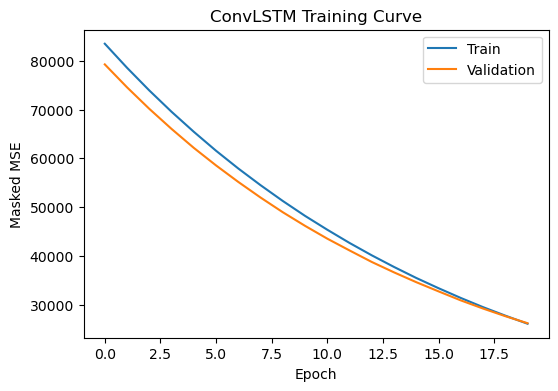

In [15]:
# ================= LOAD BEST =================
model.load_state_dict(torch.load(best_path))
print("Best model loaded.")

# ================= PLOT =================
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Masked MSE")
plt.title("ConvLSTM Training Curve")
plt.legend()
plt.show()

## 7. Testing

### 7.1 inference + save predictions

If you don’t want to run inference, the test predictions from the **best model (20 epochs)** are available at `s3://spatiotemporal-results/convlstm/test_preds_20epochs.zarr.tar.gz`. Download that artifact and proceed with the downstream steps.

In [16]:
PRED_ZARR = run_dir / "test_preds_20epochs.zarr"

if PRED_ZARR.exists():
    raise FileExistsError(
        f"Prediction store already exists: {PRED_ZARR}\n"
        "Delete it or rename"
    )


n_ws = test_ds.n_watersheds
samples_per_ws = test_ds.samples_per_ws
H = test_ds.elev.shape[1]
W = test_ds.elev.shape[2]
pred_arr = np.empty((n_ws, samples_per_ws, H, W), dtype=np.float32)

# Load best checkpoint
model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()
print("Loaded best:", best_path)

idx = 0
with torch.no_grad():
    for X, y, mask in tqdm(test_loader):
        X = X.to(device, non_blocking=True)
        with torch.amp.autocast("cuda"):
            pred = model(X)  # (B,1,H,W)
        pred = pred.squeeze(1).float().cpu().numpy()  # (B,H,W)

        B = pred.shape[0] 
        for b in range(B):
            ws = idx // samples_per_ws
            d = idx %  samples_per_ws
            pred_arr[ws, d] = pred[b]
            idx += 1 
# Save to zarr
pred_ds = xr.Dataset(
    {"swe_pred": (("watershed", "day", "y", "x"), pred_arr)},
    coords={
        "watershed": ds["watershed"].values,
        "day": ds.day[test_mask][SEQ_LEN-1:],
        "y": ds["y"].values,
        "x": ds["x"].values,
    },
)        
pred_ds.to_zarr(PRED_ZARR, mode="w", consolidated=True)
print("✅ Saved predictions to:", PRED_ZARR)

Loaded best: iter_6_full/best_convlstm.pt


100%|██████████| 1948/1948 [07:37<00:00,  4.26it/s]
/opt/conda/lib/python3.12/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=10, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)


✅ Saved predictions to: iter_6_full/test_preds_20epochs.zarr


/opt/conda/lib/python3.12/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


### 7.2 pixel level evaluation from saved predictions

In [17]:
eval_ds = ds.sel(day=ds.day[test_mask][SEQ_LEN-1:]) 
eval_ds

<xarray.Dataset> Size: 3GB
Dimensions:     (watershed: 91, y: 24, x: 24, day: 2740)
Coordinates:
  * watershed   (watershed) <U10 4kB '1701030201' '1701030202' ... '1711000907'
  * y           (y) int32 96B 0 1 2 3 4 5 6 7 8 9 ... 15 16 17 18 19 20 21 22 23
  * x           (x) int32 96B 0 1 2 3 4 5 6 7 8 9 ... 15 16 17 18 19 20 21 22 23
  * day         (day) datetime64[ns] 22kB 2015-03-31 2015-04-01 ... 2022-09-29
Data variables: (12/14)
    elev        (watershed, y, x) float32 210kB dask.array<chunksize=(1, 24, 24), meta=np.ndarray>
    huc12_id    (watershed, y, x) int64 419kB dask.array<chunksize=(1, 24, 24), meta=np.ndarray>
    lat         (watershed, y, x) float32 210kB dask.array<chunksize=(1, 24, 24), meta=np.ndarray>
    lon         (watershed, y, x) float32 210kB dask.array<chunksize=(1, 24, 24), meta=np.ndarray>
    mask        (watershed, y, x) uint8 52kB dask.array<chunksize=(1, 24, 24), meta=np.ndarray>
    pr          (watershed, day, y, x) float32 574MB dask.array<chunksize=(1, 2740, 6, 12), meta=np.ndarray>
    ...          ...
    swe_target  (watershed, day, y, x) float32 574MB dask.array<chunksize=(1, 2740, 6, 12), meta=np.ndarray>
    swe_today   (watershed, day, y, x) float32 574MB dask.array<chunksize=(1, 2740, 6, 12), meta=np.ndarray>
    tavg        (watershed, day, y, x) float32 574MB dask.array<chunksize=(1, 2740, 6, 12), meta=np.ndarray>
    valid_swe   (watershed, y, x) uint8 52kB dask.array<chunksize=(1, 24, 24), meta=np.ndarray>
    x5070       (watershed, y, x) float32 210kB dask.array<chunksize=(1, 24, 24), meta=np.ndarray>
    y5070       (watershed, y, x) float32 210kB dask.array<chunksize=(1, 24, 24), meta=np.ndarray>
Attributes: (12/14)
    huc10_id:                  1701030201
    huc10_height:              5
    huc10_width:               8
    final_size_height:         24
    final_size_width:          24
    placement_top:             9
    ...                        ...
    crs:                       EPSG:5070
    snow_class_flag_values:    [1, 2, 3, 4, 5, 6, 7, 8]
    snow_class_flag_meanings:  tundra boreal_forest maritime ephemeral prairi...
    huc12_id_note:             int64 HUC12 code per pixel; 0 = outside HUC10 ...
    valid_swe_note:            1 = inside HUC10 and no day is NaN at this pix...
    note:                      Values sampled by bilinear interpolation at 4k...

In [18]:
eval_ds = ds.sel(day=ds.day[test_mask][SEQ_LEN-1:]) 
pred_ds = xr.open_zarr(PRED_ZARR, consolidated=True)

pred = pred_ds["swe_pred"]    # (watershed, day, y, x)
true = eval_ds["swe_target"]  # (watershed, day, y, x)

valid_pix = eval_ds["valid_swe"].astype(bool)          # (watershed, y, x)
valid = valid_pix.broadcast_like(true)                 # (watershed, day, y, x)

# --- Sanity check: predictions must be finite on valid pixels ---
bad_pred = (~np.isfinite(pred)) & valid
n_bad = int(bad_pred.sum().compute())
print("Bad pred count on valid pixels:", n_bad)
assert n_bad == 0, "Model produced NaN/Inf predictions on valid pixels!"

# --- Squared error ---
err2 = (pred - true) ** 2

/opt/conda/lib/python3.12/site-packages/dask/array/core.py:5189: PerformanceWarning: Increasing number of chunks by factor of 22
  result = blockwise(


Bad pred count on valid pixels: 0


In [19]:
# -------- Global MSE --------
global_sse = (err2 * valid).sum().compute().item()
global_cnt = valid.sum().compute().item()
global_mse = global_sse / max(global_cnt, 1.0)
print("Global masked test MSE:", global_mse)
global_rmse = np.sqrt(global_mse)
print("Global RMSE (mm):", global_rmse)

Global masked test MSE: 29418.80239498515
Global RMSE (mm): 171.51910212855344


In [20]:
# -------- HUC12-wise MSE --------

# --- Stack once for group-wise metrics ---
err2_stack = err2.stack(pixel=("watershed", "y", "x"))    # (day, pixel)
valid_pix_stack = valid.stack(pixel=("watershed", "y", "x"))   # (day, pixel)

huc12_lbl = eval_ds["huc12_id"].stack(pixel=("watershed", "y", "x")).compute().data
huc12 = xr.DataArray(huc12_lbl, dims=("pixel",), name="huc12_id")

sse_by_huc12 = (err2_stack * valid_pix_stack).groupby(huc12).sum(dim=("day", "pixel"))
cnt_by_huc12 = valid_pix_stack.groupby(huc12).sum(dim=("day", "pixel"))
mse_by_huc12 = sse_by_huc12 / cnt_by_huc12

df_huc12 = mse_by_huc12.to_pandas().reset_index()
df_huc12.columns = ["huc12_id", "mse"]
df_huc12 = df_huc12[df_huc12["huc12_id"] != 0]  # drop outside bucket
df_huc12["rmse_mm"] = np.sqrt(df_huc12["mse"]) 
print(df_huc12)

/opt/conda/lib/python3.12/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


         huc12_id           mse     rmse_mm
1    170103020101   4630.909489   68.050786
2    170103020102   5195.340563   72.078711
3    170103020103   4277.857908   65.405335
4    170103020201   3586.373431   59.886338
5    170103020202   2207.760036   46.986807
..            ...           ...         ...
531  171100090601    987.160584   31.419112
532  171100090602  48442.319416  220.096159
533  171100090603   4070.936253   63.803889
534  171100090701     32.426054    5.694388
535  171100090702   6049.466788   77.778318

[535 rows x 3 columns]


In [21]:
# -------- Snowclass-wise MSE --------
snow_lbl  = eval_ds["snow_class"].stack(pixel=("watershed", "y", "x")).compute().data # (pixel,)
snow = xr.DataArray(snow_lbl,  dims=("pixel",), name="snow_class")

sse_by_snow = (err2_stack * valid_pix_stack).groupby(snow).sum(dim=("day", "pixel"))
cnt_by_snow = valid_pix_stack.groupby(snow).sum(dim=("day", "pixel"))
mse_by_snow = sse_by_snow / cnt_by_snow

df_snow = mse_by_snow.to_pandas().reset_index()
df_snow.columns = ["snow_class", "mse"]
df_snow = df_snow[df_snow["snow_class"] != 0]  # drop outside bucket
df_snow = df_snow.sort_values("snow_class")
df_snow["rmse_mm"] = np.sqrt(df_snow["mse"])

# Add snow class names from attrs 
vals = eval_ds.attrs.get("snow_class_flag_values", [])
names = eval_ds.attrs.get("snow_class_flag_meanings", "").split()
mapping = dict(zip(vals, names)) if vals and names else {}
df_snow["snow_class_name"] = df_snow["snow_class"].map(mapping)

print(df_snow)

   snow_class            mse     rmse_mm snow_class_name
1           1  170773.675912  413.247717          tundra
2           2  131442.239121  362.549637   boreal_forest
3           3   73872.237265  271.794476        maritime
4           4    1997.193846   44.689975       ephemeral
5           5    5074.135558   71.232967         prairie
6           6    6277.678577   79.231803  montane_forest


/opt/conda/lib/python3.12/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


### 7.3 Huc12 level comparision

In [24]:
# 1) Stack to flatten pixels: (watershed,y,x) -> "pixel"
pred_s  = pred.stack(pixel=("watershed","y","x"))     # (day, pixel)
true_s  = true.stack(pixel=("watershed","y","x"))     # (day, pixel)
valid_s = valid.stack(pixel=("watershed","y","x"))    # (day, pixel)

# 2) Create huc12 label for each pixel (pixel,)
huc12 = eval_ds["huc12_id"].stack(pixel=("watershed","y","x")).compute()
# huc12 dims: (pixel,)

# 3) Compute per-(day,huc12) mean of pred and true using sums / counts
pred_sum = pred_s.where(valid_s).groupby(huc12).sum("pixel")   # (day, huc12)
true_sum = true_s.where(valid_s).groupby(huc12).sum("pixel")   # (day, huc12)
cnt      = valid_s.astype(float).groupby(huc12).sum("pixel")   # (day, huc12)

pred_huc12 = pred_sum / cnt
true_huc12 = true_sum / cnt

# 4) Drop huc12_id==0 (outside bucket)
pred_huc12 = pred_huc12.sel(huc12_id=pred_huc12["huc12_id"] != 0)
true_huc12 = true_huc12.sel(huc12_id=true_huc12["huc12_id"] != 0)
cnt        = cnt.sel(huc12_id=cnt["huc12_id"] != 0)

In [59]:
# -------- Global MSE --------

err2_huc12 = (pred_huc12 - true_huc12) ** 2
err2_huc12 = err2_huc12.where(cnt > 0)

mse_huc12 = err2_huc12.mean(dim=("day","huc12_id")).compute().item()
rmse_huc12 = float(np.sqrt(mse_huc12))

print("HUC12-global mean MSE:", mse_huc12)
print("HUC12-global mean RMSE (mm):", rmse_huc12)

HUC12-global mean MSE: 22609.978087044277
HUC12-global mean RMSE (mm): 150.36614674535048


In [85]:
# --- Per-HUC12 MSE (HUC12-mean SWE evaluation) ---
# err2_huc12 dims: (day, huc12_id), with NaNs where cnt==0
mse_per_huc12 = err2_huc12.mean(dim="day", skipna=True).compute()     # (huc12_id,)
rmse_per_huc12 = np.sqrt(mse_per_huc12)

df_huc12_mean = (
    mse_per_huc12.to_pandas()
    .reset_index()
    .rename(columns={0: "mse"})
)
df_huc12_mean["rmse_mm"] = np.sqrt(df_huc12_mean["mse"])

df_huc12_mean

,huc12_id,mse,rmse_mm
0,170103020101,3229.549654,56.829127
1,170103020102,2798.650342,52.902272
2,170103020103,4021.845848,63.418025
3,170103020201,2533.370419,50.332598
4,170103020202,1537.137868,39.206350
...,...,...,...
530,171100090601,619.568703,24.891137
531,171100090602,22076.121036,148.580352
532,171100090603,1297.131824,36.015716
533,171100090701,28.766072,5.363401


In [86]:
# KGE calculation
p = pred_huc12   # (day, huc12_id)
o = true_huc12   # (day, huc12_id)

# ---- 1) Strict invalid checks per HUC12 ----
# any NaN anywhere in the time series => bad
bad_nan = xr.ufuncs.isnan(p).any("day") | xr.ufuncs.isnan(o).any("day")

# std checks (std==0) => bad
std_p = p.std("day")   # (huc12_id,)
std_o = o.std("day")   # (huc12_id,)
bad_std = (std_p == 0) | (std_o == 0)

# optional but recommended: mean(o)==0 makes beta undefined
mu_p = p.mean("day")
mu_o = o.mean("day")
bad_mean = (mu_o == 0)

bad = bad_nan | bad_std | bad_mean   # (huc12_id,)

# ---- 2) Compute components for ALL basins (vectorized) ----
# correlation r
p_anom = p - mu_p
o_anom = o - mu_o
r = (p_anom * o_anom).mean("day") / (std_p * std_o)

# alpha, beta
alpha = std_p / std_o
beta  = mu_p / mu_o

# KGE
kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

# ---- 3) Apply strict masking: if bad => everything NaN ----
kge   = kge.where(~bad)
kge

<xarray.DataArray (huc12_id: 535)> Size: 4kB
dask.array<where, shape=(535,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * huc12_id  (huc12_id) int64 4kB 170103020101 170103020102 ... 171100090702

In [87]:
# Convert KGE to pandas Series indexed by huc12_id
kge_series = kge.compute().to_pandas()
kge_series.name = "kge"

# Add as column into your existing dataframe
df_huc12_mean = df_huc12_mean.merge(
    kge_series.reset_index(),
    on="huc12_id",
    how="left"
)

df_huc12_mean

,huc12_id,mse,rmse_mm,kge
0,170103020101,3229.549654,56.829127,0.856647
1,170103020102,2798.650342,52.902272,0.841030
2,170103020103,4021.845848,63.418025,0.876558
3,170103020201,2533.370419,50.332598,0.896791
4,170103020202,1537.137868,39.206350,0.816862
...,...,...,...,...
530,171100090601,619.568703,24.891137,0.765075
531,171100090602,22076.121036,148.580352,0.338129
532,171100090603,1297.131824,36.015716,0.665728
533,171100090701,28.766072,5.363401,-0.693568


In [88]:
# --- Majority snowtype per HUC12 (mode over pixels) ---

# Flatten to 1D arrays over pixels
snow_pix  = eval_ds["snow_class"].stack(pixel=("watershed","y","x")).compute().data.astype(np.int16)  # (P,)
huc12_pix = eval_ds["huc12_id"].stack(pixel=("watershed","y","x")).compute().data.astype(np.int64)   # (P,)
valid_pix = valid.isel(day=0).stack(pixel=("watershed","y","x")).compute().data.astype(bool)         # (P,)

# Keep valid pixels and real HUC12 ids
m = valid_pix & (huc12_pix != 0) & (snow_pix != 0)
snow_v  = snow_pix[m]
huc12_v = huc12_pix[m]

# Build majority label per HUC12 by counting (huc12, snow_class)
# Trick: encode pair into a single integer key
max_snow = int(snow_v.max())
keys = huc12_v * (max_snow + 1) + snow_v   # unique per (huc12, snow)

uniq_keys, counts = np.unique(keys, return_counts=True)

# Decode back
uniq_huc12 = uniq_keys // (max_snow + 1)
uniq_snow  = uniq_keys %  (max_snow + 1)

df_counts = pd.DataFrame({"huc12_id": uniq_huc12, "snow_class": uniq_snow, "n_pix": counts})
# Majority snowtype per HUC12 = max n_pix within each huc12
df_major = (
    df_counts.sort_values(["huc12_id", "n_pix"], ascending=[True, False])
    .drop_duplicates("huc12_id")
    .rename(columns={"snow_class": "major_snow_class", "n_pix": "major_n_pix"})
    .reset_index(drop=True)
)

# map class id -> name using dataset attributes
snow_names = str(ds.attrs.get("snow_class_flag_meanings", "")).split()
# snow class ids are 1..len(snow_names)
snow_id_to_name = {i+1: snow_names[i] for i in range(len(snow_names))}

df_major["snow_class_name"] = df_major["major_snow_class"].map(snow_id_to_name)
df_major = df_major.drop(columns=["major_snow_class", "major_n_pix"])
df_major

,huc12_id,snow_class_name
0,170103020101,montane_forest
1,170103020102,montane_forest
2,170103020103,montane_forest
3,170103020201,montane_forest
4,170103020202,montane_forest
...,...,...
530,171100090601,ephemeral
531,171100090602,maritime
532,171100090603,maritime
533,171100090701,ephemeral


In [89]:
# Merge majority snow type onto per-HUC12 error table
df_huc12_mean = df_huc12_mean.merge(df_major, on="huc12_id", how="left")
df_huc12_mean.head()

,huc12_id,mse,rmse_mm,kge,snow_class_name
0,170103020101,3229.549654,56.829127,0.856647,montane_forest
1,170103020102,2798.650342,52.902272,0.841030,montane_forest
2,170103020103,4021.845848,63.418025,0.876558,montane_forest
3,170103020201,2533.370419,50.332598,0.896791,montane_forest
4,170103020202,1537.137868,39.206350,0.816862,montane_forest


In [90]:
df_their = pd.read_csv("huc12_snow_types.csv")
df_their = df_their.rename(columns={"huc12": "huc12_id","snow_type": "lstm_snowtype"})
# Merge lstm snow type onto per-HUC12 error table
df_huc12_mean = df_huc12_mean.merge(df_their, on="huc12_id", how="left")
# 4) Add HUC8 from HUC12 (first 8 digits)
df_huc12_mean["huc8_id"] = (df_huc12_mean["huc12_id"] // 10_000).astype("int64")
df_huc12_mean

,huc12_id,mse,rmse_mm,kge,snow_class_name,lstm_snowtype,huc8_id
0,170103020101,3229.549654,56.829127,0.856647,montane_forest,Montane Forest,17010302
1,170103020102,2798.650342,52.902272,0.841030,montane_forest,Montane Forest,17010302
2,170103020103,4021.845848,63.418025,0.876558,montane_forest,Montane Forest,17010302
3,170103020201,2533.370419,50.332598,0.896791,montane_forest,Montane Forest,17010302
4,170103020202,1537.137868,39.206350,0.816862,montane_forest,Montane Forest,17010302
...,...,...,...,...,...,...,...
530,171100090601,619.568703,24.891137,0.765075,ephemeral,Ephemeral,17110009
531,171100090602,22076.121036,148.580352,0.338129,maritime,Ephemeral,17110009
532,171100090603,1297.131824,36.015716,0.665728,maritime,Ephemeral,17110009
533,171100090701,28.766072,5.363401,-0.693568,ephemeral,Ephemeral,17110009


In [91]:
# Each HUC12 counts equally (matches the spirit of HUC12-level evaluation)
df_snow_huc12 = (
    df_huc12_mean
    .groupby(["lstm_snowtype"], dropna=False)
    .agg(
        n_huc12=("huc12_id","count"),

        mean_mse=("mse","mean"),
        median_mse=("mse","median"),

        mean_rmse_mm=("rmse_mm","mean"),
        median_rmse_mm=("rmse_mm","median"),

        mean_kge=("kge","mean"),
        median_kge=("kge","median"),
    )
    .reset_index()
    .sort_values("mean_kge", ascending=False)   # better ordering for hydrology
)

df_snow_huc12

,lstm_snowtype,n_huc12,mean_mse,median_mse,mean_rmse_mm,median_rmse_mm,mean_kge,median_kge
3,Montane Forest,185,4564.331693,2040.387490,56.377112,45.170649,0.822214,0.869220
4,Prairie,11,2560.333760,474.031293,38.914009,21.772260,0.773530,0.798723
5,NaN,4,2308.827024,2067.427398,44.871580,42.948678,0.715003,0.716859
1,Ephemeral,180,903.086067,181.223099,20.961244,13.461895,0.508213,0.589200
0,Boreal Forest,1,41705.368068,41705.368068,204.218922,204.218922,0.419970,0.419970
2,Maritime,154,71495.305674,45119.563317,236.124282,212.413609,0.389386,0.370610


(2740,) (2740,)


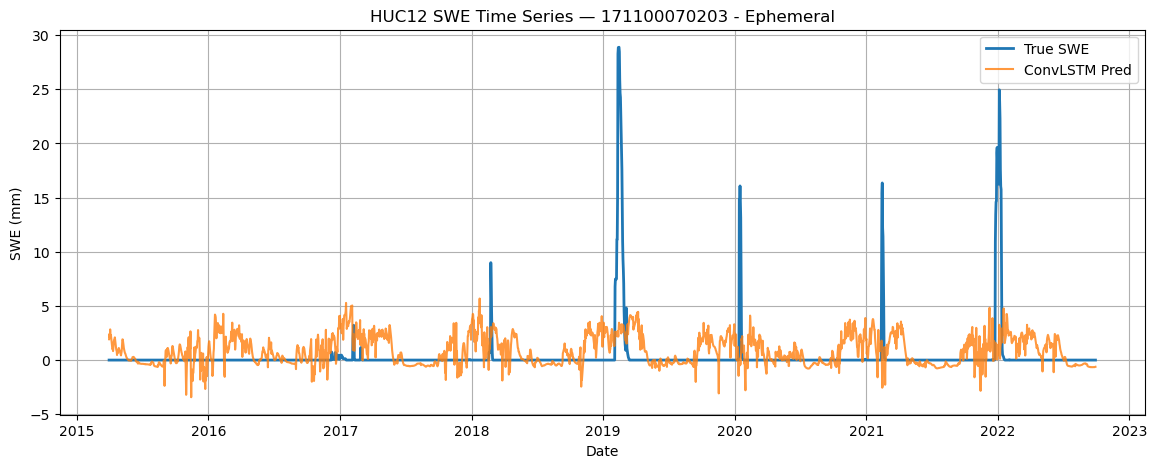

In [92]:
import matplotlib.pyplot as plt

HUC = 171100070203   # <- ephemeral

# Select series
pred_series = pred_huc12.sel(huc12_id=HUC).compute()
true_series = true_huc12.sel(huc12_id=HUC).compute()

print(pred_series.shape, true_series.shape)
plt.figure(figsize=(14,5))

plt.plot(true_series["day"], true_series, label="True SWE", linewidth=2)
plt.plot(pred_series["day"], pred_series, label="ConvLSTM Pred", alpha=0.8)

plt.title(f"HUC12 SWE Time Series — {HUC} - Ephemeral")
plt.xlabel("Date")
plt.ylabel("SWE (mm)")
plt.legend()
plt.grid(True)

plt.show()

(2740,) (2740,)


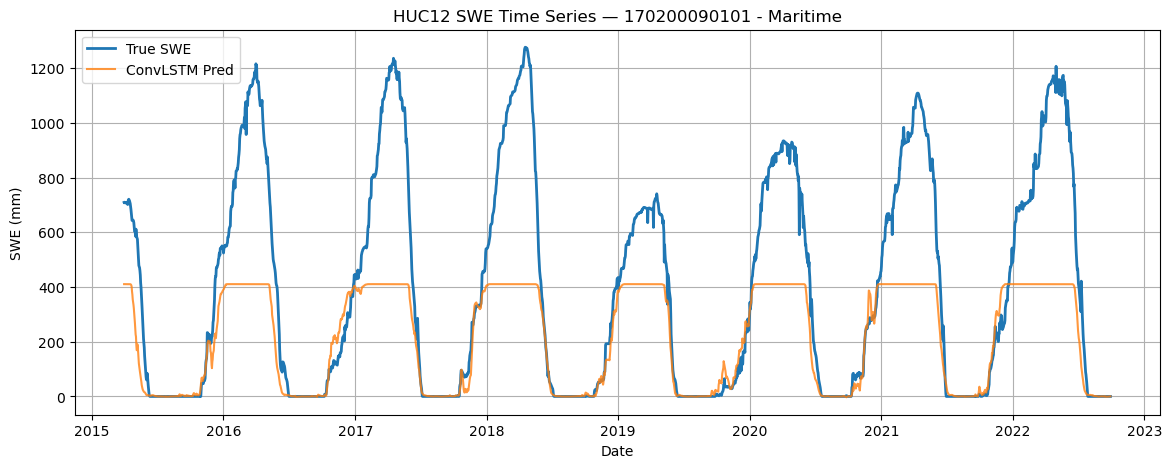

In [93]:
import matplotlib.pyplot as plt

HUC = 170200090101   # <- Maritime	

# Select series
pred_series = pred_huc12.sel(huc12_id=HUC).compute()
true_series = true_huc12.sel(huc12_id=HUC).compute()

print(pred_series.shape, true_series.shape)
plt.figure(figsize=(14,5))

plt.plot(true_series["day"], true_series, label="True SWE", linewidth=2)
plt.plot(pred_series["day"], pred_series, label="ConvLSTM Pred", alpha=0.8)

plt.title(f"HUC12 SWE Time Series — {HUC} - Maritime")
plt.xlabel("Date")
plt.ylabel("SWE (mm)")
plt.legend()
plt.grid(True)

plt.show()

(2740,) (2740,)


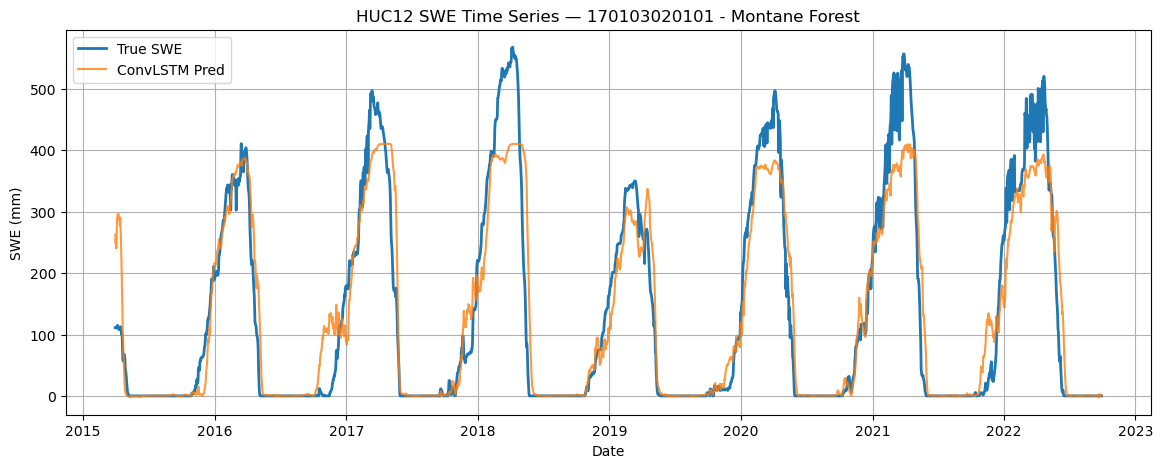

In [94]:
import matplotlib.pyplot as plt

HUC = 170103020101   # <- the basin you want - montane

# Select series
pred_series = pred_huc12.sel(huc12_id=HUC).compute()
true_series = true_huc12.sel(huc12_id=HUC).compute()

print(pred_series.shape, true_series.shape)
plt.figure(figsize=(14,5))

plt.plot(true_series["day"], true_series, label="True SWE", linewidth=2)
plt.plot(pred_series["day"], pred_series, label="ConvLSTM Pred", alpha=0.8)

plt.title(f"HUC12 SWE Time Series — {HUC} - Montane Forest")
plt.xlabel("Date")
plt.ylabel("SWE (mm)")
plt.legend()
plt.grid(True)

plt.show()

### 7.4 Save to compare with LSTM

In [97]:
df_huc12_mean.head()

,huc12_id,mse,rmse_mm,kge,snow_class_name,lstm_snowtype,huc8_id
0,170103020101,3229.549654,56.829127,0.856647,montane_forest,Montane Forest,17010302
1,170103020102,2798.650342,52.902272,0.841030,montane_forest,Montane Forest,17010302
2,170103020103,4021.845848,63.418025,0.876558,montane_forest,Montane Forest,17010302
3,170103020201,2533.370419,50.332598,0.896791,montane_forest,Montane Forest,17010302
4,170103020202,1537.137868,39.206350,0.816862,montane_forest,Montane Forest,17010302


In [98]:
df_comparision = (
    df_huc12_mean[["huc12_id", "huc8_id", "lstm_snowtype", "mse", "kge"]]
    .rename(columns={
        "huc12_id": "huc12",
        "huc8_id": "huc8",
        "lstm_snowtype": "snow_type"
    })
    .sort_values("huc12")
    .reset_index(drop=True)
)

df_comparision.head()

,huc12,huc8,snow_type,mse,kge
0,170103020101,17010302,Montane Forest,3229.549654,0.856647
1,170103020102,17010302,Montane Forest,2798.650342,0.841030
2,170103020103,17010302,Montane Forest,4021.845848,0.876558
3,170103020201,17010302,Montane Forest,2533.370419,0.896791
4,170103020202,17010302,Montane Forest,1537.137868,0.816862


In [99]:
df_comparision.to_csv("convlstm_results.csv", index=False)
print("Saved to convlstm.csv")

Saved to convlstm.csv


In [100]:
# Count NaNs in each column
df_comparision.isna().sum()


huc12        0
huc8         0
snow_type    4
mse          0
kge          0
dtype: int64